# Cleaning: Reducing dataset - GRA, correlation, balanced features

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import folium
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import squareform

In [2]:
df = pd.read_parquet("010_data_cleaned.parquet").copy()
print('Number of people involved: ', df.shape[0],
      '\nNumber of variables:          ', df.shape[1],
      '\nNumber of accidents:       ', df['Protocollo'].nunique())

Number of people involved:  19406 
Number of variables:           65 
Number of accidents:        17944


### COLUMNS INVENTORY

What are the existing columns?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19406 entries, 0 to 19405
Data columns (total 65 columns):
 #   Column                            Non-Null Count  Dtype                      
---  ------                            --------------  -----                      
 0   Protocollo                        19406 non-null  Int64                      
 1   DataOraIncidente                  19406 non-null  datetime64[ns, Europe/Rome]
 2   Gruppo                            19406 non-null  Int64                      
 3   Localizzazione1                   19406 non-null  object                     
 4   STRADA1                           19406 non-null  object                     
 5   Localizzazione2                   19406 non-null  object                     
 6   STRADA2                           19406 non-null  object                     
 7   Strada02                          19406 non-null  object                     
 8   Chilometrica                      19406 non-null  object

Are there any null values in any columns?

In [4]:
df.isna().sum().sum()

0

# DETECT IRRELEVANT FEATURES

#### Drop unnecessary columns:

- Gruppo, "STRADA1", "Localizzazione2", "STRADA2", "Strada02", "Chilometrica", "DaSpecificare" - which police group reported the accident (rough areas) and other geographical information no longer needed as we have the Latitude and Longitude of each accident. 

- YEAR, MONTH are temporal markers, but we are more concerned with the lighting and weather conditions which occur, rather than which month or which year. Other temporal features include time of day, day and twilight phases. Seasonal effects in lighting and weather are captured in other features. The final year of the dataset, 2022 only has up to August, so this would skew analysis. The inclusion of years where lockdowns took place due to Covid would also skew traffic and pedestrian circulation (lockdown 2020 from February, etc). 

- 'accident_type' - adds little information as all accidents involve pedestrians being run over. We will check the balance before deciding whether to drop this feature. 

- "Localizzazione1" - again, little information is added regarding the type of road. We will check the balance before deciding whether to drop this feature. 

In [5]:
cols_to_drop = ["Gruppo", "STRADA1", "Localizzazione2", "STRADA2",
                "Strada02", "Chilometrica", "DaSpecificare", 'YEAR', 'MONTH']

df = df.drop(columns=cols_to_drop)

In [6]:
check_relevance_cols = ['accident_type', 'Localizzazione1']

for col in check_relevance_cols:
    print(f"\n{col}")
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    out = pd.concat([counts, pct], axis=1)
    out.columns = ["Count", "%"]
    print(out)


accident_type
                                 Count     %
accident_type                               
accident_pedestrian_run_over     19135  98.6
accident_obstacle_hit              142   0.7
accident_parked_vehicle_hit         75   0.4
accident_vehicle_out_of_control     53   0.3
accident_type_unknown                1   0.0

Localizzazione1
                             Count     %
Localizzazione1                         
Strada Urbana                18618  95.9
Statale entro l'abitato        240   1.2
Provinciale entro l'abitato    198   1.0
Regionale entro l'abitato      143   0.7
Provinciale                     59   0.3
Altra strada                    58   0.3
Statale                         40   0.2
Comunale extraurbana            30   0.2
Regionale                       20   0.1


The type of accident feature is also very unbalanced; 98.6% of accidents were pedestrian_run_over this is perhaps a reporting issue as pedestrians were hurt in all of the accidents included. We can delete this feature.

The type of road (Localizzazione1) does not help us discriminate between different accidents as 96% occur on urban roads and each of the other types account for a very small proportion of roads. Cutting the analysis to urban roads could help us focus on in-Rome accidents.

In [7]:
before = len(df)

mask = df["Localizzazione1"].fillna("").str.strip().eq("Strada Urbana")
df = df.loc[mask].copy()

print(f"Kept {len(df)} / {before} rows (only 'Strada Urbana'). "
      f"Dropped {before - len(df)}.")

Kept 18618 / 19406 rows (only 'Strada Urbana'). Dropped 788.


In [8]:
df = df.drop(columns=check_relevance_cols)

In [9]:
df.shape

(18618, 54)

### REDUCTION OF DATASET

Currently the dataset is 'per pedestrian'; this means that if a driver hits more than one pedestrian, the circumstances (weather conditions, time of day, road features, etc) of that accident are over-represented. We want to consider the severity of the accident but not over-inflate the importance of the conditions in our dataset. In addition, this means that not every datapoint is independent of the others. 

New variables: 
- total_pedestrian_injury (sum of all pedestrian injuries)
- max_pedestrian_injury (worst single injury)
- num_pedestrians_hit (count)
- num_male_pedestrians
- num_female_pedestrians
- num_unknown_pedestrians

We take the information from the features:
'pedestrian_gender',
'pedestrian_injury',

This means we are considering the total = burden of the accident (more people injured) and max = extremity of the outcome (was there at least one death?)

In [10]:
df['Protocollo'].value_counts().head(3)

Protocollo
3896598    7
4648602    6
5927947    5
Name: count, dtype: Int64

The highest number of pedestrians involved is 7

In [11]:
for n in range(1, 9):
    print(n, " pedestrians: ", (df['Protocollo'].value_counts() == n).sum())

1  pedestrians:  15937
2  pedestrians:  1171
3  pedestrians:  89
4  pedestrians:  11
5  pedestrians:  3
6  pedestrians:  1
7  pedestrians:  1
8  pedestrians:  0


There are also many accidents with 2-7 pedestrians. 

In [12]:
from typing import Optional


def aggregate_pedestrians(
    df: pd.DataFrame,
    accident_id: str = "Protocollo",
    gender_col: str = "pedestrian_gender",
    injury_col: str = "pedestrian_injury"
) -> pd.DataFrame:
    """
    Aggregate per-pedestrian data to accident-level with injury and demographic summaries.

    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with one row per pedestrian
    accident_id : str
        Column name containing accident identifier
    gender_col : str  
        Column name containing pedestrian gender (M/F/U or similar)
    injury_col : str
        Column name containing injury severity (0-4 scale)

    Returns:
    --------
    pd.DataFrame
        Accident-level dataframe with aggregated pedestrian information
    """

    # Validate required columns
    required_cols = [accident_id, injury_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    # Clean and standardize gender
    if gender_col in df.columns:
        gender_clean = (df[gender_col]
                        .astype(str)
                        .str.strip()
                        .str.upper()
                        .replace({'NAN': np.nan, 'NONE': np.nan}))

        # Map to standard categories
        gender_clean = gender_clean.map({'M': 'M', 'F': 'F'}).fillna('U')
    else:
        print(
            f"Warning: {gender_col} not found. Setting all genders to Unknown.")
        gender_clean = pd.Series('U', index=df.index)

    # Clean and validate injury severity
    injury_clean = pd.to_numeric(df[injury_col], errors='coerce')

    # Handle invalid injury values
    invalid_injuries = injury_clean.isna()
    if invalid_injuries.any():
        print(
            f"Warning: {invalid_injuries.sum()} invalid injury values found. Setting to 0 (uninjured).")

    injury_clean = injury_clean.fillna(0).clip(0, 4).astype(int)

    # Add cleaned columns to dataframe for aggregation
    df_temp = df.assign(
        gender_clean=gender_clean,
        injury_clean=injury_clean,
        is_male=(gender_clean == 'M').astype(int),
        is_female=(gender_clean == 'F').astype(int),
        is_unknown=(gender_clean == 'U').astype(int)
    )

    # Create aggregation dictionary with actual column names
    agg_dict = {
        'injury_clean': ['sum', 'max', 'count'],
        'is_male': 'sum',
        'is_female': 'sum',
        'is_unknown': 'sum'
    }

    # Perform aggregation
    result = (df_temp.groupby(accident_id, dropna=False)
              .agg(agg_dict)
              .reset_index())

    # Flatten and rename columns
    result.columns = [accident_id] + [
        'total_injury_severity', 'max_injury_severity', 'num_pedestrians_hit',
        'num_male', 'num_female', 'num_unknown_gender'
    ]

    # Add multiple pedestrians indicator
    result['multiple_pedestrians'] = (
        result['num_pedestrians_hit'] > 1).astype(int)

    # Validation checks
    _validate_results(result)

    return result


def _validate_results(df: pd.DataFrame) -> None:
    """Internal validation of aggregation results."""

    # Check gender counts sum correctly
    gender_sum = df['num_male'] + df['num_female'] + df['num_unknown_gender']
    gender_mismatch = df['num_pedestrians_hit'] != gender_sum

    if gender_mismatch.any():
        print(
            f"Warning: {gender_mismatch.sum()} accidents have gender count mismatches.")

    # Check injury logic
    max_gt_total = df['max_injury_severity'] > df['total_injury_severity']
    if max_gt_total.any():
        print(
            f"Error: {max_gt_total.sum()} accidents have max_injury > total_injury.")

    # Check injury ranges
    invalid_max = ~df['max_injury_severity'].between(0, 4)
    if invalid_max.any():
        print(
            f"Warning: {invalid_max.sum()} accidents have max_injury outside 0-4 range.")

    # Summary statistics
    multi_ped = (df['num_pedestrians_hit'] > 1).sum()
    print(f"\nAggregation Summary:")
    print(f"- Total accidents: {len(df):,}")
    print(
        f"- Multi-pedestrian accidents: {multi_ped:,} ({multi_ped/len(df):.1%})")
    print(
        f"- Average pedestrians per accident: {df['num_pedestrians_hit'].mean():.2f}")
    print(
        f"- Max pedestrians in single accident: {df['num_pedestrians_hit'].max()}")

In [13]:
df_accidents = aggregate_pedestrians(
    df,
    accident_id="Protocollo",
    gender_col="pedestrian_gender",
    injury_col="pedestrian_injury"
)

print("\nResulting columns:")
print(df_accidents.columns.tolist())
print(f"\nDataset reduced from {len(df):,} to {len(df_accidents):,} rows")


Aggregation Summary:
- Total accidents: 17,213
- Multi-pedestrian accidents: 1,276 (7.4%)
- Average pedestrians per accident: 1.08
- Max pedestrians in single accident: 7

Resulting columns:
['Protocollo', 'total_injury_severity', 'max_injury_severity', 'num_pedestrians_hit', 'num_male', 'num_female', 'num_unknown_gender', 'multiple_pedestrians']

Dataset reduced from 18,618 to 17,213 rows


In [14]:
df_accidents['max_injury_severity'].value_counts()

max_injury_severity
1    14180
0     2096
2      537
4      213
3      187
Name: count, dtype: int64

In [15]:
df_accidents['total_injury_severity'].value_counts()

total_injury_severity
1    13372
0     2096
2     1257
3      252
4      208
5       19
6        6
8        2
7        1
Name: count, dtype: int64

In [16]:
def analyze_injury_severity_distribution(df, severity_col='total_injury_severity'):
    """
    Analyze the distribution of total injury severity and identify outliers.
    """
    print("TOTAL INJURY SEVERITY DISTRIBUTION ANALYSIS")
    print("=" * 50)

    # Basic statistics
    total_accidents = len(df)
    severity_counts = df[severity_col].value_counts().sort_index()

    print(f"Total accidents: {total_accidents:,}\n")

    # Show full distribution
    print("Complete Distribution:")
    for severity, count in severity_counts.items():
        pct = (count / total_accidents) * 100
        print(f"Severity {severity:2d}: {count:5,} accidents ({pct:4.1f}%)")

    print("\n" + "=" * 50)

    # Split into common vs extreme cases
    common_accidents = df[df[severity_col] <= 4]
    extreme_accidents = df[df[severity_col] > 4]

    # Statistical summary
    print("STATISTICAL SUMMARY:")
    print("-" * 20)
    print(f"Mean severity: {df[severity_col].mean():.2f}")
    print(f"Median severity: {df[severity_col].median():.1f}")
    print(f"Standard deviation: {df[severity_col].std():.2f}")
    print(f"95th percentile: {df[severity_col].quantile(0.95):.1f}")
    print(f"99th percentile: {df[severity_col].quantile(0.99):.1f}")
    print(f"Maximum severity: {df[severity_col].max()}")

    print("CATEGORIZED ANALYSIS:")
    print("-" * 30)

    # Common accidents (0-4)
    common_count = len(common_accidents)
    common_pct = (common_count / total_accidents) * 100

    print(f"**Common accidents ({common_pct:.1f}% of data):**")
    print(f"• Severity 0-4: {common_count:,} accidents")
    print("• These represent single pedestrians or typical multi-pedestrian incidents")

    print(f"\nBreakdown of common accidents:")
    for severity in range(5):
        if severity in severity_counts:
            count = severity_counts[severity]
            pct = (count / common_count) * 100
            print(f"  - Severity {severity}: {count:,} ({pct:.1f}% of common)")

    print(f"\n**Rare extreme cases ({100-common_pct:.1f}% of data):**")

    # Extreme accidents (5+)
    extreme_count = len(extreme_accidents)
    print(f"• Severity 5+: {extreme_count} accidents total")

    return {
        'total_accidents': total_accidents,
        'common_accidents': common_count,
        'extreme_accidents': extreme_count,
        'severity_distribution': severity_counts.to_dict()
    }

In [17]:
results = analyze_injury_severity_distribution(
    df_accidents, 'total_injury_severity')

# Show just the extreme cases in detail
print("\n" + "=" * 50)
print("DETAILED VIEW OF EXTREME CASES:")
print("-" * 30)

extreme_cases = df_accidents[df_accidents['total_injury_severity'] > 4]
if len(extreme_cases) > 0:
    print(f"\nShowing all {len(extreme_cases)} extreme cases:")
    extreme_summary = extreme_cases[[
        'total_injury_severity', 'max_injury_severity', 'num_pedestrians_hit']].copy()
    extreme_summary = extreme_summary.sort_values(
        'total_injury_severity', ascending=False)

    for idx, row in extreme_summary.iterrows():
        total_sev = row['total_injury_severity']
        max_sev = row['max_injury_severity']
        num_peds = row['num_pedestrians_hit']
        print(
            f"Accident {idx}: {num_peds} pedestrians, total severity {total_sev}, max individual severity {max_sev}")
else:
    print("No extreme cases found.")

TOTAL INJURY SEVERITY DISTRIBUTION ANALYSIS
Total accidents: 17,213

Complete Distribution:
Severity  0: 2,096 accidents (12.2%)
Severity  1: 13,372 accidents (77.7%)
Severity  2: 1,257 accidents ( 7.3%)
Severity  3:   252 accidents ( 1.5%)
Severity  4:   208 accidents ( 1.2%)
Severity  5:    19 accidents ( 0.1%)
Severity  6:     6 accidents ( 0.0%)
Severity  7:     1 accidents ( 0.0%)
Severity  8:     2 accidents ( 0.0%)

STATISTICAL SUMMARY:
--------------------
Mean severity: 1.02
Median severity: 1.0
Standard deviation: 0.63
95th percentile: 2.0
99th percentile: 4.0
Maximum severity: 8
CATEGORIZED ANALYSIS:
------------------------------
**Common accidents (99.8% of data):**
• Severity 0-4: 17,185 accidents
• These represent single pedestrians or typical multi-pedestrian incidents

Breakdown of common accidents:
  - Severity 0: 2,096 (12.2% of common)
  - Severity 1: 13,372 (77.8% of common)
  - Severity 2: 1,257 (7.3% of common)
  - Severity 3: 252 (1.5% of common)
  - Severity 4:

There are 28 'extreme' accidents where multiple pedestrians were killed or hurt. Only in three cases, the accident did not have fatal consequences for anyone.

Now in our new dataset, df_accidents, each point represents an accident, not a pedestrian. 

This means that where an accident involved more than one pedestrian, the conditions (weather, lighting, traffic density, etc) were being duplicated in our dataset on the basis of the number of pedestrians counted. In the new dataset, that bias is removed as each set of conditions is only included once. Now it is easier to measure: what are the conditions which occur when severe accidents occur?  

We have taken the pedestrian with the worst injuries in each protocol as max_injury_severity, but not copied over the gender of that specific pedestrian in order to avoid the possibility of bias if the pedestrian injury correlates with other victim characteristics. We have kept a clear count of the number of male and female pedestrians involved, and the total number involved. 

In [18]:
upper_threshold = df_accidents['total_injury_severity'].quantile(
    0.99)  # 99th percentile
upper_threshold

4.0

In [19]:
df_accidents['severity_winsorized'] = df_accidents['total_injury_severity'].clip(
    upper=upper_threshold)

Here we have effectively capped the extreme 28 cases at a severity level of 4 (99th percentile). This means that those accidents have been retained but 'severity_winsorized' gives us a severity level equal to the 99th percentile, 4, rather than 5-8 as we were seeing before. This reduces the leverage of those outliers without deleting the datapoints. This will allow us the measure the 'usual' severity of an accident.  

In [20]:
df_accidents['severity_winsorized'].value_counts()

severity_winsorized
1    13372
0     2096
2     1257
3      252
4      236
Name: count, dtype: int64

In [21]:
df_accidents.columns

Index(['Protocollo', 'total_injury_severity', 'max_injury_severity',
       'num_pedestrians_hit', 'num_male', 'num_female', 'num_unknown_gender',
       'multiple_pedestrians', 'severity_winsorized'],
      dtype='object')

In [22]:
df.columns

Index(['Protocollo', 'DataOraIncidente', 'Latitude', 'Longitude',
       'parked_vehicle_involved', 'driver_injury', 'driver_gender',
       'passenger_no_of_females', 'passenger_no_of_males',
       'passenger_no_of_unknown_sex', 'passengers_killed',
       'passengers_uninjured', 'passengers_injured', 'phase_of_day', 'DAY',
       'pedestrian_gender', 'road_conditions', 'road_markings_absent',
       'road_markings_onroad', 'road_markings_signposts',
       'road_markings_temporary', 'road_features',
       'road_markings_traffic_lights', 'road_surface', 'TipoStradaDifficulty',
       'visibility', 'pedestrian_injury', 'lighting_insufficient',
       'traffic_density', 'vehicle_type', 'vehicle_unknown', 'hit_and_run',
       'temperature_2m (°C)', 'relative_humidity_2m (%)', 'rain (mm)',
       'precipitation (mm)', 'apparent_temperature (°C)', 'snowfall (cm)',
       'snow_depth (m)', 'surface_pressure (hPa)', 'weather_code (wmo code)',
       'cloud_cover (%)', 'wind_speed_10m (km/

Now we join on Protocol:

In [23]:
print("Per pedestrian dataframe shape: ", df.shape)
print("Per accident dataframe shape: ", df_accidents.shape)

Per pedestrian dataframe shape:  (18618, 54)
Per accident dataframe shape:  (17213, 9)


In [24]:
# 1) Columns to pull over from df
cols_to_pull = [
    'DataOraIncidente', 'Latitude', 'Longitude',
    'parked_vehicle_involved', 'driver_injury', 'driver_gender',
    'passenger_no_of_females', 'passenger_no_of_males', 'passenger_no_of_unknown_sex',
    'passengers_uninjured', 'passengers_injured', 'phase_of_day', 'DAY',
    'road_conditions', 'road_markings_absent', 'road_markings_onroad',
    'road_markings_signposts', 'road_markings_temporary', 'road_features',
    'road_markings_traffic_lights', 'road_surface', 'TipoStradaDifficulty',
    'visibility', 'lighting_insufficient', 'traffic_density', 'vehicle_type',
    'vehicle_unknown', 'hit_and_run', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
    'rain (mm)', 'precipitation (mm)', 'apparent_temperature (°C)', 'snowfall (cm)',
    'snow_depth (m)', 'surface_pressure (hPa)', 'weather_code (wmo code)',
    'cloud_cover (%)', 'wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)',
    'weather_condition_noted', 'weather_wet', 'weather_snowy',
    'weather_days_since_last_rain', 'weather_cumulative_rain_past_24h',
    'doy_sin', 'doy_cos', 'time_sin', 'time_cos'
]

# 2) One row per Protocollo from df (pick the row with worst pedestrian_injury)
df = df.copy()
df['ped_injury_num'] = pd.to_numeric(
    df['pedestrian_injury'], errors='coerce').fillna(-1)

idx = df.groupby('Protocollo')['ped_injury_num'].idxmax()
df_info = df.loc[idx, ['Protocollo'] + cols_to_pull]

# 3) Merge into the accidents-level table
df_accidents = df_accidents.merge(
    df_info, on='Protocollo', how='left', validate='one_to_one'
)

In [25]:
df_accidents.shape

(17213, 58)

### CHECK FOR UNBALANCED FEATURES

If a feature has a specific value for the vast majority of rows, we should consider dropping it as it will not help us differentiate between the circumstances in which accidents occur. 

In [26]:
def analyze_multiple_features_for_rare_values(df, feature_list, threshold=0.05):
    """
    Analyze multiple features for rare values and return candidates for deletion.
    Shows detailed analysis for each feature, then provides summary.

    Parameters:
    df: pandas DataFrame - the data to analyze
    feature_list: list - list of column names to analyze
    threshold: float - minimum percentage (default 0.05 for 5%)

    Returns:
    list - feature names that have rare values (candidates for deletion)
    """
    candidates_for_deletion = []

    print("RARE VALUES ANALYSIS FOR MULTIPLE FEATURES")
    print("=" * 60)

    for feature in feature_list:
        if feature in df.columns:
            # Analyze each feature (inline analysis)
            series = df[feature]
            value_counts = series.value_counts()
            total_count = len(series)

            # Calculate percentages
            percentages = value_counts / total_count
            rare_mask = percentages < threshold

            # Get largest percentage
            largest_percentage = percentages.max()
            most_common_value = percentages.idxmax()

            # Check if has rare values
            has_rare_values = rare_mask.any()

            # Print results for this feature
            print(f"\nFeature: {feature}")
            print(f"Has Rare Values: {has_rare_values}")

            if has_rare_values:
                rare_values = percentages[rare_mask].index.tolist()
                rare_percentages = percentages[rare_mask].to_dict()

                print(f"Rare Values: {rare_values}")
                print(f"Rare Percentages: {rare_percentages}")

                # Add to candidates list
                candidates_for_deletion.append(feature)
            else:
                print("Rare Values: None")
                print("Rare Percentages: None")

            print(
                f"Largest Percentage: {largest_percentage*100:.2f}% for value '{most_common_value}'")

        else:
            print(f"\nWarning: Feature '{feature}' not found in DataFrame")

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("-" * 20)
    print(
        f"Total features analyzed: {len([f for f in feature_list if f in df.columns])}")
    print(f"Features with rare values: {len(candidates_for_deletion)}")
    print(f"Threshold used: {threshold*100}%")

    if candidates_for_deletion:
        print(f"\nCandidates for deletion:")
        for i, feature in enumerate(candidates_for_deletion, 1):
            print(f"  {i}. {feature}")
    else:
        print("\nNo features have rare values below the threshold.")

    return candidates_for_deletion

Columns to apply this to: 
- 'parked_vehicle_involved',
- 'driver_injury',
- 'driver_gender',
- 'passenger_no_of_females',
- 'passenger_no_of_males',
- 'passenger_no_of_unknown_sex',
- 'passengers_uninjured',
- 'passengers_injured',
- 'road_features',
- 'road_markings_traffic_lights',
- 'road_surface',
- 'TipoStradaDifficulty',
- 'visibility',
- 'lighting_insufficient',
- 'traffic_density',
- 'hit_and_run',
- 'snowfall (cm)',
- 'snow_depth (m)',
- 'weather_snowy'

In [27]:
check_relevance_cols2 = ['parked_vehicle_involved', 'driver_injury', 'driver_gender',
                         'passenger_no_of_females', 'passenger_no_of_males', 'passenger_no_of_unknown_sex',
                         'passengers_uninjured', 'passengers_injured', 'road_features', 'road_markings_traffic_lights',
                         'road_surface', 'TipoStradaDifficulty', 'visibility', 'lighting_insufficient', 'traffic_density',
                         'hit_and_run', 'snowfall (cm)', 'snow_depth (m)', 'weather_snowy'
                         ]

candidates_for_deletion = analyze_multiple_features_for_rare_values(
    df_accidents,
    check_relevance_cols2,
    threshold=0.05
)

RARE VALUES ANALYSIS FOR MULTIPLE FEATURES

Feature: parked_vehicle_involved
Has Rare Values: True
Rare Values: [1]
Rare Percentages: {1: 0.010166734444896299}
Largest Percentage: 98.98% for value '0'

Feature: driver_injury
Has Rare Values: True
Rare Values: ['2', '4', '3']
Rare Percentages: {'2': 0.0009295300063905188, '4': 0.00017428687619822227, '3': 5.8095625399407424e-05}
Largest Percentage: 93.78% for value '0'

Feature: driver_gender
Has Rare Values: False
Rare Values: None
Rare Percentages: None
Largest Percentage: 73.39% for value 'M'

Feature: passenger_no_of_females
Has Rare Values: True
Rare Values: [2, 3, 4]
Rare Percentages: {2: 0.010515308197292744, 3: 0.001917155638180445, 4: 0.0002323825015976297}
Largest Percentage: 90.18% for value '0'

Feature: passenger_no_of_males
Has Rare Values: True
Rare Values: [2, 3, 4, 7, 5]
Rare Percentages: {2: 0.006739092546331261, 3: 0.0008714343809911114, 4: 0.0002323825015976297, 7: 5.8095625399407424e-05, 5: 5.8095625399407424e-05}
L

In [28]:
candidates_for_deletion

['parked_vehicle_involved',
 'driver_injury',
 'passenger_no_of_females',
 'passenger_no_of_males',
 'passenger_no_of_unknown_sex',
 'passengers_uninjured',
 'passengers_injured',
 'road_features',
 'road_surface',
 'visibility',
 'lighting_insufficient',
 'hit_and_run',
 'snowfall (cm)',
 'snow_depth (m)',
 'weather_snowy']

- 'parked_vehicle_involved',    DELETE
-  'driver_injury',             COLLAPSE
-  'passenger_no_of_females',        SEE BELOW - PASSENGERS
-  'passenger_no_of_males',          SEE BELOW - PASSENGERS
-  'passenger_no_of_unknown_sex',    SEE BELOW - PASSENGERS
-  'passengers_uninjured',           SEE BELOW - PASSENGERS
-  'passengers_injured',             SEE BELOW - PASSENGERS
-  'road_features',             COLLAPSE
-  'road_surface',              DELETE
-  'visibility',                COLLAPSE
-  'lighting_insufficient',     DELETE
-  'hit_and_run',               KEEP as very close to 5%, could show a pattern
-  'snowfall (cm)',             DELETE
-  'snow_depth (m)',            DELETE
-  'weather_snowy'              DELETE

In [29]:
features_to_delete = ['parked_vehicle_involved', 'road_surface', 'lighting_insufficient',
                      'snowfall (cm)', 'snow_depth (m)', 'weather_snowy']

df_accidents.drop(columns=features_to_delete, inplace=True)

### Collapse categories: driver_injury
Driver injury counts indicate an unbalanced dataset with some important information at the tail end. In this case, we will collapse the tail of injury 2, 3, 4 into category 2 (severe injury and death is lumped into one group)

In [30]:
df_accidents['driver_injury'].value_counts()

driver_injury
0    16143
1     1050
2       16
4        3
3        1
Name: count, dtype: Int64

In [31]:
df_accidents['driver_injury'] = pd.to_numeric(
    df_accidents['driver_injury'], errors='coerce')
df_accidents['driver_injury'] = (
    df_accidents['driver_injury'] > 0).astype('int8')  # 0/1

In [32]:
df_accidents['driver_injury'].value_counts()

driver_injury
0    16143
1     1070
Name: count, dtype: int64

driver_injury is now binary with 0 = uninjured, 1 = injured

### Collapse categories: Features involving passengers

We are interested in the number of passengers (is this a distraction to the driver? Should local police focus stop and checks on vehicles with many passengers / single drivers?)

We could therefore introduce the feature 'total_passengers', collapsing the individual counts of male, female, unknown into 0 passengers, 1 passenger, many passengers.

In [33]:
df_accidents["total_passengers"] = (
    df_accidents["passenger_no_of_females"]
    + df_accidents["passenger_no_of_males"]
    + df_accidents["passenger_no_of_unknown_sex"]
)

In [34]:
df_accidents['total_passengers'].value_counts(dropna=False)

total_passengers
0    14458
1     2248
2      374
3      101
4       25
5        4
7        3
Name: count, dtype: int64

In [35]:
# Create categorical feature: 0 = "0 passengers", 1 = "1 passenger", 2 = "many passengers"
df_accidents['passengers'] = np.where(df_accidents['total_passengers'] == 0, 0,
                                      np.where(df_accidents['total_passengers'] == 1, 1, 2))

# Check the result
print(df_accidents['passengers'].value_counts().sort_index())

passengers
0    14458
1     2248
2      507
Name: count, dtype: int64


'passengers' is now essentially categorical: 0 no passengers, 1 is a passenger, 2 is more than one passenger

In order to preserve information about passenger injury, we can turn 'passengers_injured' into a binary column which will be 1 if any passenger is injured. 

In [36]:
df_accidents['passengers_injured'].value_counts(dropna=False)

passengers_injured
0    17112
1       98
2        2
3        1
Name: count, dtype: int64

Although passengers injured only account for 115 cases (0.5% of the total cases) this is actually 4% of all cases where there are passengers at all. As this is such a minority of cases, we can drop the information about passenger injury. 

In [37]:
passenger_cols_to_drop = [
    "passenger_no_of_females",
    "passenger_no_of_males",
    "passenger_no_of_unknown_sex",
    "passengers_injured",
    "passengers_uninjured",
    "total_passengers"
]

# Drop the original features to reduce multicollinearity
df_accidents = df_accidents.drop(columns=passenger_cols_to_drop)

### Collapse categories: road_features

In [38]:
df_accidents['road_features'].value_counts(normalize=True, dropna=False)

road_features
Straight road         0.655609
Intersection          0.273224
Curve                 0.042177
Roundabout            0.017196
Slope                 0.008714
road_feature_other    0.003079
Name: proportion, dtype: float64

In [39]:
# Define mapping: keep main categories, collapse the rest into 'Other'
feature_map = {
    'Straight road': 'Straight road',
    'Intersection': 'Intersection',
    'Curve': 'Curve',
    'Roundabout': 'Other',
    'Slope': 'Other',
    'road_feature_other': 'Other'
}

df_accidents['road_features'] = (
    df_accidents['road_features']
    .map(feature_map)
    .astype('category')
)

print(df_accidents['road_features'].value_counts(dropna=False))

road_features
Straight road    11285
Intersection      4703
Curve              726
Other              499
Name: count, dtype: int64


Now each category is better populated. 

### Collapse categories: visibility

In [40]:
df_accidents['visibility'].value_counts(normalize=True, dropna=False)

visibility
2    0.783594
1    0.186429
0    0.029977
Name: proportion, dtype: float64

The original coding was: 'Buona': 2, 'Sufficiente': 1, 'Insufficiente': 0. However, we are only really interested in cases where there was insufficient visibility. There are too few cases if we collapse the categories into OK (2 and 1) and Poor (0); this would become a 97% - 3% split. We will therefore delete this feature. 

In [41]:
df_accidents.drop(columns='visibility', inplace=True)

## UNBALANCED FEATURES

Features where we may need to collapse categories:
- 'phase_of_day',
- 'road_conditions',
- 'road_markings_temporary',
- 'road_features',
- 'vehicle_type',
- 'vehicle_unknown',
- 'weather_condition_noted'

### Category collapse: phase_of_day

In [43]:
df_accidents['phase_of_day'].value_counts(
    normalize=True, dropna=False).round(2)

phase_of_day
time_daylight_am                 0.36
time_daylight_pm                 0.33
time_night_pm                    0.13
time_nautical_twilight_pm        0.05
time_astronomical_twilight_pm    0.04
time_civil_twilight_pm           0.04
time_night_am                    0.02
time_civil_twilight_am           0.01
time_nautical_twilight_am        0.01
time_astronomical_twilight_am    0.00
Name: proportion, dtype: float64

In [47]:
# 1) Mapping: 10 → 3 bands
phase_map = {
    "time_daylight_am": "light_day",
    "time_daylight_pm": "light_day",

    "time_night_am": "light_night",
    "time_night_pm": "light_night",

    "time_astronomical_twilight_am": "light_twilight",
    "time_nautical_twilight_am":     "light_twilight",
    "time_civil_twilight_am":        "light_twilight",

    "time_astronomical_twilight_pm": "light_twilight",
    "time_nautical_twilight_pm":     "light_twilight",
    "time_civil_twilight_pm":        "light_twilight",
}

# 2) Create the collapsed column
df_accidents["natural_light"] = df_accidents["phase_of_day"].map(phase_map)

# 3) Make it a categorical
order = ["light_night", "light_twilight", "light_day"]
df_accidents["natural_light"] = pd.Categorical(
    df_accidents["natural_light"], categories=order, ordered=True)

# 4) Quick check: counts + percentages
counts = df_accidents["natural_light"].value_counts().reindex(
    order, fill_value=0)
pct = (
    df_accidents["natural_light"]
    .value_counts(normalize=True)
    .mul(100).round(2)
    .reindex(order, fill_value=0)
)

# Drop phase_of_day feature
df_accidents.drop(columns=['phase_of_day'], errors='ignore', inplace=True)

summary = pd.concat([counts.rename("Count"), pct.rename("%")], axis=1)
print(summary)

                Count      %
natural_light               
light_night      2581  14.99
light_twilight   2693  15.65
light_day       11939  69.36


Leaving 10 categories, or even collapsing them to 6 (differentiating between twilight morning and twilight evening, etc) left at least two of the categories are very small. We will use other features to measure the time of day and this will merely measure natural light. 

### Category collapse: 'road_conditions'

In [48]:
df_accidents['road_conditions'].value_counts(dropna=False)

road_conditions
dry                        14288
wet                         2898
slippery                      15
icy                           11
road_conditions_unknown        1
Name: count, dtype: int64

In [49]:
# Binary collapse: 0 = dry, 1 = everything else (wet, slippery, icy)
cond_map = {
    'dry': 0,
    'wet': 1,
    'slippery': 1,
    'icy': 1,
    'road_conditions_unknown': np.nan  # mark unknown as missing
}

df_accidents['road_conditions_bin'] = (
    df_accidents['road_conditions']
    .map(cond_map)
    .astype('float')   # will hold NaN for the unknown
)

# Drop the single unknown row
df_accidents = df_accidents.dropna(subset=['road_conditions_bin'])

# Convert to int now that NaN is gone
df_accidents['road_conditions_bin'] = df_accidents['road_conditions_bin'].astype(
    'int8')

# Quick check
print(df_accidents['road_conditions_bin'].value_counts(dropna=False))

road_conditions_bin
0    14288
1     2924
Name: count, dtype: int64


### Category collapse: road_markings_temporary

This feature has a category which has been identified as a low percentage. However, it is part of a group of variables:

In [50]:
road_markings_columns = [
    col for col in df_accidents.columns if "road_markings" in col]

for x in road_markings_columns:
    print(df_accidents[x].value_counts(dropna=False), "\n")

road_markings_absent
0    15820
1     1392
Name: count, dtype: int64 

road_markings_onroad
1    15148
0     2064
Name: count, dtype: int64 

road_markings_signposts
1    13306
0     3906
Name: count, dtype: int64 

road_markings_temporary
0    17164
1       48
Name: count, dtype: int64 

road_markings_traffic_lights
0    15884
1     1328
Name: count, dtype: int64 



In [51]:
# Build combined category for absent OR temporary (priority first)
df_accidents["road_signage"] = np.select(
    [
        (df_accidents["road_markings_absent"] == 1) | (
            df_accidents["road_markings_temporary"] == 1),
        (df_accidents["road_markings_onroad"] == 1) & (
            df_accidents["road_markings_signposts"] == 1),
        (df_accidents["road_markings_onroad"] == 1) & (
            df_accidents["road_markings_signposts"] == 0),
        (df_accidents["road_markings_onroad"] == 0) & (
            df_accidents["road_markings_signposts"] == 1),
    ],
    ["absent_temp", "both", "onroad", "signposts"],
    default=np.nan  # all zeros or missing → leave as NaN
)

df_accidents["road_signage"] = pd.Categorical(
    df_accidents["road_signage"],
    categories=["absent_temp", "onroad", "signposts", "both"],
    ordered=False
)

# Drop rows where classification was not possible (NaN)
df_accidents = df_accidents.dropna(
    subset=["road_signage"]).reset_index(drop=True)

# Check changes
df_accidents['road_signage'].value_counts(dropna=False)

road_signage
both           12683
onroad          2465
absent_temp     1440
signposts        623
Name: count, dtype: int64

In [52]:
df_accidents = df_accidents.drop(columns=["road_markings_absent", "road_markings_onroad",
                                          "road_markings_signposts", "road_markings_temporary"]).reset_index(drop=True)

### Category collapse: vehicle_type & vehicle_unknown

In [53]:
df_accidents['vehicle_type'].value_counts(
    normalize=True, dropna=False).round(2)

vehicle_type
4.0        0.68
3.0        0.19
5.0        0.04
unknown    0.03
7.0        0.02
2.0        0.01
1.0        0.01
9.0        0.00
6.0        0.00
8.0        0.00
Name: proportion, dtype: float64

Collapse vehicle type categories:

In [54]:
def collapse_vehicle_type(s):
    if s in ["1.0", "2.0"]:
        return "1.0_2.0"
    elif s in ["6.0", "7.0", "8.0", "9.0"]:
        return "6.0_plus"
    elif s in ["4.0", "3.0", "5.0", "unknown"]:
        return s
    else:
        return "Other"  # safety net for unexpected values


df_accidents["vehicle_type"] = df_accidents["vehicle_type"].astype(
    str).map(collapse_vehicle_type)

In [55]:
# Map collapsed vehicle_type codes to human-readable labels
vehicle_labels = {
    "4.0": "Car",
    "3.0": "Motorcycle_or_scooter",
    "5.0": "Van",
    "unknown": "Unknown",
    "1.0_2.0": "Bicycle_or_Moped",
    "6.0_plus": "Heavy_or_Special"
}

df_accidents["vehicle_type"] = df_accidents["vehicle_type"].astype(
    str).map(vehicle_labels).astype("category")

In [56]:
print(df_accidents["vehicle_type"].value_counts(
    normalize=True).mul(100).round(2))

vehicle_type
Car                      68.49
Motorcycle_or_scooter    19.19
Van                       4.42
Unknown                   3.28
Heavy_or_Special          2.37
Bicycle_or_Moped          2.26
Name: proportion, dtype: float64


This may not leave us with enough cases in each category. 

In [57]:
from scipy.stats import chi2_contingency

tab = pd.crosstab(df_accidents['vehicle_type'],
                  df_accidents['severity_winsorized'])
chi2, p, *_ = chi2_contingency(tab)
# if p < 0.05 and effect size isn't tiny, keep the split

print(f"p is {p}, chi squared is {chi2}")

p is 1.2457856508228517e-13, chi squared is 105.58330864983131


This indicates that the vehicle type and injury severity aren’t independent, so we will check further:

In [58]:
from scipy.stats import chi2_contingency, norm

tab = pd.crosstab(df_accidents['vehicle_type'],
                  df_accidents['severity_winsorized'])
chi2, p, dof, exp = chi2_contingency(tab)
N = tab.to_numpy().sum()
r, c = tab.shape
V = np.sqrt(chi2 / (N * min(r-1, c-1)))

std_resid = (tab - exp) / np.sqrt(exp)               # standardized residuals
contrib = (tab - exp)**2 / exp                       # cell χ² contributions
exp_min = exp.min()
n_lt5 = (exp < 5).sum()

# Post-hoc two-sided p for each cell (BH-FDR correction)
z = std_resid.to_numpy().ravel()
p_cell = 2*norm.sf(np.abs(z))
rank = p_cell.argsort().argsort() + 1
p_fdr = p_cell * (len(p_cell) / rank)
p_fdr = np.minimum(1.0, p_fdr).reshape(std_resid.shape)

print(f"chi2={chi2:.2f}, p={p:.2e}, dof={dof}, CramersV={V:.3f}, "
      f"exp_min={exp_min:.2f}, expected<5: {n_lt5}")

chi2=105.58, p=1.25e-13, dof=20, CramersV=0.039, exp_min=5.33, expected<5: 0


χ²(20)=105.58, p=1.25e−13 → statistically significant (big N).

Cramér’s V = 0.039 → negligible effect size.

exp_min = 5.33, expected<5 = 0 → no small-cell problems.

The global association with severity is tiny, so merging or keeping the small classes is a modeling/interpretability choice, not a statistical necessity.

However there is also the vehicle_unknown columns, which we can now delete.

In [59]:
df_accidents = df_accidents.drop(columns=['vehicle_unknown'], axis=1)

### Category collapse: 'weather_condition_noted'

In [60]:
df_accidents['weather_condition_noted'].value_counts(dropna=False)

weather_condition_noted
Clear          12454
Cloudy          2933
Rain            1687
Blazing sun       65
Fog               63
Strong wind        6
Hail               2
Haze               1
Name: count, dtype: int64

The weather conditions noted by police could be better balanced with the regrouping of the rare categories into one. However, we also have weather information from weather_code (wmo code):

In [61]:
df_accidents['weather_code (wmo code)'].value_counts()

weather_code (wmo code)
0     6973
3     3065
1     2596
2     1640
51    1605
53     581
61     395
63     189
55     156
65       7
71       3
73       1
Name: count, dtype: int64

The WMO weather codes correspond to these states:
- w_..0 → Cloud development not observed or no clouds
- w_..1 → Clouds generally dissolving or becoming less developed
- w_..2 → State of sky unchanged
- w_..3 → Clouds generally forming or developing
- w_..51, 53, 55 → Drizzle (light, moderate, dense)
- w_..61, 63, 65 → Rain (light, moderate, heavy)
- w_..71, 73 → Snow (light, moderate)

Which we could simplify to: 
- Clear	0, 1, 2
- Cloudy	3
- Drizzle	51, 53, 55
- Rain	61, 63, 65
- Snow	71, 73

In [62]:
df_accidents['weather_code'] = df_accidents['weather_code (wmo code)'].map({
    0: 'Clear',
    1: 'Clear',
    2: 'Clear',
    3: 'Cloudy',
    51: 'Drizzle',
    53: 'Drizzle',
    55: 'Drizzle',
    61: 'Rain',
    63: 'Rain',
    65: 'Rain',
    71: 'Snow',
    73: 'Snow'
})

In [63]:
# Drop the original 'weather_code (wmo code)' column
df_accidents = df_accidents.drop('weather_code (wmo code)', axis=1)
df_accidents['weather_code'].value_counts()

weather_code
Clear      11209
Cloudy      3065
Drizzle     2342
Rain         591
Snow           4
Name: count, dtype: int64

In [64]:
# Create cross-tabulation
weather_crosstab = pd.crosstab(df_accidents['weather_code'],
                               df_accidents['weather_condition_noted'],
                               margins=True)

print(weather_crosstab)

weather_condition_noted  Rain  Cloudy  Clear  Fog  Hail  Blazing sun  \
weather_code                                                           
Clear                     193     937   9982   36     0           59   
Cloudy                    281     912   1850   13     0            5   
Drizzle                   866     893    570   11     1            1   
Rain                      345     189     52    3     1            0   
Snow                        2       2      0    0     0            0   
All                      1687    2933  12454   63     2           65   

weather_condition_noted  Strong wind  Haze    All  
weather_code                                       
Clear                              2     0  11209  
Cloudy                             3     1   3065  
Drizzle                            0     0   2342  
Rain                               1     0    591  
Snow                               0     0      4  
All                                6     1  17211  


The 'conditions noted' problematic categories are: fog, hail, blazing sun, strong wind and haze, and 'weather code' categories: snow. 

The discrepancies could be due to recording issues, or to the sometimes vast distance between some accidents and the weather centre giving the forecast. 

We could also try cutting the geographical area down to accidents inside the GRA, to restrict our analysis to urban roads. 

In [65]:
# Extract unique weather codes for replacement
weather_code_values = df_accidents['weather_code'].unique()

# Update categories of 'weather_condition_noted'
current_categories = df_accidents['weather_condition_noted'].cat.categories.tolist(
)
new_categories = current_categories + [
    x for x in weather_code_values if x not in current_categories]
df_accidents['weather_condition_noted'] = df_accidents['weather_condition_noted'].cat.add_categories(
    [x for x in weather_code_values if x not in current_categories])

# Perform the replacement
mask = df_accidents['weather_condition_noted'].isin(
    ['Hail', 'Strong wind', 'Haze'])
df_accidents.loc[mask,
                 'weather_condition_noted'] = df_accidents.loc[mask, 'weather_code']

mask = df_accidents['weather_code'] == 'Snow'
df_accidents.loc[mask, 'weather_code'] = df_accidents.loc[mask,
                                                          'weather_condition_noted']

In [66]:
# Create cross-tabulation
weather_crosstab = pd.crosstab(df_accidents['weather_code'],
                               df_accidents['weather_condition_noted'],
                               margins=True)

print(weather_crosstab)

weather_condition_noted  Rain  Cloudy  Clear  Fog  Blazing sun  Drizzle    All
weather_code                                                                  
Clear                     193     937   9984   36           59        0  11209
Cloudy                    281     918   1850   13            5        0   3067
Drizzle                   866     893    570   11            1        1   2342
Rain                      349     189     52    3            0        0    593
All                      1689    2937  12456   63           65        1  17211


#### RESTRICTION OF GEOGRAPHICAL AREA

Rome's centre is considered to be Latitude 41.892 and Longitude 12.511. 
The Grande Raccordo Annulare is approximately between 
- Latitude 41.794 and 41.991
- Longitude 12.373 and 12.616     

In [67]:
# Filter accidents to keep only those within specified geographic bounds
# Keep rows where Latitude and Longitude are between the specified values:
lat_max = 41.991
lat_min = 41.794
long_max = 12.616
long_min = 12.373

df_filtered = df_accidents.query(
    f'{lat_min} <= Latitude <= {lat_max} and {long_min} <= Longitude <= {long_max}')

# Display results
print(f"Original dataset size: {len(df_accidents)} rows")
print(f"Filtered dataset size: {len(df_filtered)} rows")
print(f"Removed {len(df_accidents) - len(df_filtered)} rows")

# Update the original dataframe
df_accidents = df_filtered

Original dataset size: 17211 rows
Filtered dataset size: 15169 rows
Removed 2042 rows


The rectangle drawn around the city cuts out most points outside of the Grande Raccordo. 
### SOUTH_WEST CORNER CUT
Two accident locations were identified to cut off accidents outside the GRA on the southwest corner

In [68]:
lat_A = 41.8090     # On the GRA, west of Via del Mare
long_A = 12.4112

lat_B = 41.7946     # The northmost accident in Fonte Laurentina
long_B = 12.4877

We check the accuracy of the accident coordinates (rounded to 4 s.f. on the map) so the line is as defined as possible:

In [69]:
def find_closest_accident(df_accidents, lat_A, long_A, return_distance=False):
    """
    Find the closest accident to a given coordinate using Haversine distance.

    Parameters:
    -----------
    df_accidents : pd.DataFrame
        DataFrame containing accident data with 'Latitude' and 'Longitude' columns
    lat_A : float
        Latitude of the reference point
    long_A : float
        Longitude of the reference point
    return_distance : bool, default False
        If True, returns (closest_row, distance_m), otherwise just closest_row

    Returns:
    --------
    pd.Series or tuple
        If return_distance=False: Series containing the closest accident record
        If return_distance=True: Tuple of (closest_row, distance_in_meters)
    """
    # Keep only valid numeric coords
    dfc = df_accidents.copy()
    dfc["Latitude"] = pd.to_numeric(dfc["Latitude"], errors="coerce")
    dfc["Longitude"] = pd.to_numeric(dfc["Longitude"], errors="coerce")
    dfc = dfc.dropna(subset=["Latitude", "Longitude"])

    if len(dfc) == 0:
        raise ValueError("No valid coordinates found in the dataset")

    # Haversine distance (vectorized) in km
    R = 6371.0
    phi1 = np.radians(lat_A)
    phi2 = np.radians(dfc["Latitude"].to_numpy())
    dphi = np.radians(dfc["Latitude"].to_numpy() - lat_A)
    dlmb = np.radians(dfc["Longitude"].to_numpy() - long_A)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlmb/2)**2
    dist_km = 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Nearest single point
    imin = int(np.argmin(dist_km))
    closest_idx = dfc.index[imin]
    closest_row = df_accidents.loc[closest_idx]

    # Print results
    print(f"Closest accident index: {closest_idx}")
    print(
        f"Coordinates: ({closest_row['Latitude']:.6f}, {closest_row['Longitude']:.6f})")
    print(f"Distance: {dist_km[imin]*1000:.1f} m")

    if return_distance:
        return closest_row, dist_km[imin] * 1000  # distance in meters
    else:
        return closest_row

In [70]:
closest_A = find_closest_accident(df_accidents, lat_A, long_A)

Closest accident index: 10087
Coordinates: (41.808960, 12.411180)
Distance: 4.7 m


In [71]:
closest_B = find_closest_accident(df_accidents, lat_B, long_B)

Closest accident index: 13682
Coordinates: (41.794600, 12.487700)
Distance: 0.0 m


In [72]:
def calculate_boundary_from_points(lat1, lon1, lat2, lon2):
    """
    Calculate gradient (gr) and y-intercept (ce) from two geographic points.

    Parameters:
    - lat1, lon1: First point coordinates
    - lat2, lon2: Second point coordinates

    Returns:
    - gr: gradient/slope
    - ce: y-intercept
    """
    if lon2 == lon1:
        raise ValueError(
            "Points have same longitude - vertical line not supported")

    gr = (lat1 - lat2) / (lon1 - lon2)
    ce = lat1 - gr * lon1

    return gr, ce

In [73]:
gr, ce = calculate_boundary_from_points(
    closest_A['Latitude'], closest_A['Longitude'], closest_B['Latitude'], closest_B['Longitude'])

In [74]:
print(f"South-west cut uses: Latitude = Longitude x {gr} + {ce}")

South-west cut uses: Latitude = Longitude x -0.18766335598531506 + 44.13808369053782


# MAP CHECK

In [71]:
def create_accidents_map(df_accidents, gr=None, ce=None, lat_min=None, lat_max=None,
                         long_min=None, long_max=None, filename='rome_accidents_map.html'):
    """
    Create a Folium map showing accident locations with optional boundary line and rectangle.

    Parameters:
    - df_accidents: DataFrame with accident data
    - gr, ce: Line parameters (optional) - if provided, draws the boundary line
    - lat_min, lat_max, long_min, long_max: Rectangle bounds (optional)
    - filename: Output HTML filename

    Returns:
    - folium.Map object
    """

    accident_data = df_accidents
    print(f"Using data with {len(df_accidents)} accidents")

    # Create a map centered on Rome
    rome_center = [41.9028, 12.4964]

    # Create the base map
    m = folium.Map(
        location=rome_center,
        zoom_start=11,
        tiles='OpenStreetMap'
    )

    # Add accident points to the map
    for idx, row in accident_data.iterrows():
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=0.5,
            popup=f"Accident at {row['Latitude']:.4f}, {row['Longitude']:.4f}",
            color='red',
            fill=True,
            fillColor='red',
            fillOpacity=0.6
        ).add_to(m)

    # Add rectangle if bounds are provided
    if all(bound is not None for bound in [lat_min, lat_max, long_min, long_max]):
        folium.Rectangle(
            bounds=[[lat_min, long_min], [lat_max, long_max]],
            color='blue',
            weight=2,
            fill=False,
            popup="Filtered Area"
        ).add_to(m)

    # Add the boundary line if gr and ce are provided
    if gr is not None and ce is not None:
        lon_min_line = float(accident_data['Longitude'].min())
        lon_max_line = float(accident_data['Longitude'].max())

        line_points = [
            [gr * lon_min_line + ce, lon_min_line],
            [gr * lon_max_line + ce, lon_max_line]
        ]

        folium.PolyLine(
            locations=line_points,
            color='black',
            weight=2,
            opacity=0.9,
            dash_array='6, 6',  # dashed line
            tooltip=f"Latitude = {gr:.6f} * Longitude + {ce:.6f}"
        ).add_to(m)

    # Add a marker for Rome city center
    folium.Marker(
        location=rome_center,
        popup="Rome City Center",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

    # Save the map to an HTML file
    m.save(filename)
    print(f"\nMap saved as '{filename}'!")

    return None

In [72]:
# Map with latest boundary line and rectangle:
create_accidents_map(df_accidents, gr=gr, ce=ce,
                     lat_min=lat_min, lat_max=lat_max,
                     long_min=long_min, long_max=long_max)

Using data with 15169 accidents

Map saved as 'rome_accidents_map.html'!


Definition of function to cut above / below a given line

In [75]:
def filter_accidents_by_boundary(df_accidents, gr, ce, keep_above=True, verbose=True):
    """
    Filter accidents based on a linear geographic boundary.

    Parameters:
    - df_accidents: DataFrame with 'Latitude' and 'Longitude' columns
    - gr: gradient/slope of the boundary line
    - ce: y-intercept of the boundary line
    - keep_above: if True, keeps points where Latitude > (gr * Longitude + ce)
                 if False, keeps points where Latitude <= (gr * Longitude + ce)
    - verbose: if True, prints filtering statistics

    Returns:
    - df_filtered: DataFrame with filtered accidents (replaces original)
    """

    # Ensure numeric & drop rows with missing coords before filtering
    df_work = df_accidents.copy()
    df_work["Latitude"] = pd.to_numeric(df_work["Latitude"], errors="coerce")
    df_work["Longitude"] = pd.to_numeric(df_work["Longitude"], errors="coerce")

    # Remove rows with missing coordinates
    df_work = df_work.dropna(subset=["Latitude", "Longitude"])

    before = df_work.shape[0]

    # Create mask based on boundary condition
    if keep_above:
        mask = df_work["Latitude"] > (gr * df_work["Longitude"] + ce)
        filter_desc = "above"
    else:
        mask = df_work["Latitude"] <= (gr * df_work["Longitude"] + ce)
        filter_desc = "on and below"

    df_filtered = df_work.loc[mask].copy()
    df_removed = df_work.loc[~mask, ["Latitude", "Longitude"]].copy()

    if verbose:
        print(f"Original DataFrame shape: {df_accidents.shape}")
        print(f"After removing missing coords: {df_work.shape}")
        print(f"Filtered DataFrame shape: {df_filtered.shape}")
        print(f"Rows removed: {before - df_filtered.shape[0]}")
        print(f"\nKept points {filter_desc} of line: y = {gr:.6f}x + {ce:.6f}")
        if len(df_removed) > 0:
            print(f"\nFirst 10 removed points (Latitude/Longitude):")
            print(df_removed.head(10))
        else:
            print("\nNo points were removed.")

    return df_filtered

SOUTH WEST LINE TO EXCLUDE POINTS

In [76]:
# Filter accidents to keep only those within specified geographic bounds - SOUTH WEST
# Keep rows where: y > gr * x + ce  (i.e., Latitude > gr * Longitude + ce)

df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=True)

Original DataFrame shape: (15169, 44)
After removing missing coords: (15169, 44)
Filtered DataFrame shape: (15133, 44)
Rows removed: 36

Kept points above of line: y = -0.187663x + 44.138084

First 10 removed points (Latitude/Longitude):
      Latitude  Longitude
2353  41.79468   12.44245
3754  41.79825   12.44884
3840  41.79985   12.42561
3841  41.79494   12.40431
4589  41.79673   12.43121
6097  41.79484   12.40351
6579  41.79608   12.45252
6745  41.80014   12.42882
8550  41.79937   12.44794
8605  41.79604   12.40490


#### SOUTH-EAST 1st CUT

In [77]:
lat_C = 41.8935
long_C = 12.6151    # GRA & Prenestina

lat_D = 41.8397
long_D = 12.5919    # GRA & Tuscolana

In [78]:
closest_C = find_closest_accident(df_accidents, lat_C, long_C)

Closest accident index: 9378
Coordinates: (41.893460, 12.615050)
Distance: 6.1 m


In [79]:
closest_D = find_closest_accident(df_accidents, lat_D, long_D)

Closest accident index: 10798
Coordinates: (41.839700, 12.591900)
Distance: 0.0 m


In [80]:
gr, ce = calculate_boundary_from_points(
    closest_C['Latitude'], closest_C['Longitude'], closest_D['Latitude'], closest_D['Longitude'])

print(f"South-east cut uses: Latitude = Longitude x {gr} + {ce}")

South-east cut uses: Latitude = Longitude x 2.322246220302309 + 12.598207818575354


In [81]:
df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=True)

Original DataFrame shape: (15133, 44)
After removing missing coords: (15133, 44)
Filtered DataFrame shape: (14982, 44)
Rows removed: 151

Kept points above of line: y = 2.322246x + 12.598208

First 10 removed points (Latitude/Longitude):
       Latitude  Longitude
32    41.860810  12.606590
163   41.847403  12.604646
313   41.846336  12.607782
350   41.833428  12.600379
541   41.818345  12.604749
557   41.860652  12.608213
1311  41.845063  12.598675
1355  41.818966  12.611409
1411  41.860689  12.607553
1521  41.860452  12.603266


#### SOUTH-EAST 2nd CUT

In [82]:
# Lat_D
# Long_D
Lat_E = 41.8260,
Long_E = 12.5845  # GRA - Via Lucrezia Romana

In [83]:
closest_E = find_closest_accident(df_accidents, Lat_E, Long_E)

Closest accident index: 13901
Coordinates: (41.826000, 12.584500)
Distance: 0.0 m


In [84]:
gr, ce = calculate_boundary_from_points(
    closest_D['Latitude'], closest_D['Longitude'], closest_E['Latitude'], closest_E['Longitude'])

print(f"South-east 2nd cut uses: Latitude = Longitude x {gr} + {ce}")

South-east 2nd cut uses: Latitude = Longitude x 1.851351351351228 + 18.52766891892047


In [85]:
df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=True)

Original DataFrame shape: (14982, 44)
After removing missing coords: (14982, 44)
Filtered DataFrame shape: (14978, 44)
Rows removed: 4

Kept points above of line: y = 1.851351x + 18.527669

First 10 removed points (Latitude/Longitude):
        Latitude  Longitude
6150   41.808380  12.576850
10805  41.809323  12.578596
13901  41.826000  12.584500
16383  41.821100  12.582500


#### NORTH-EAST 1st CUT

In [86]:
Lat_F = 41.9752
Long_F = 12.5388    # Via A. Celi

Lat_G = 41.9590
Long_G = 12.5737   # Via Nomentana

# NB As we are cutting the part ABOVE the line this time,
# we need to pick the north-most accidents we want to keep.

In [87]:
closest_F = find_closest_accident(df_accidents, Lat_F, Long_F)

Closest accident index: 16041
Coordinates: (41.975200, 12.538800)
Distance: 0.0 m


In [88]:
closest_G = find_closest_accident(df_accidents, Lat_G, Long_G)

Closest accident index: 15193
Coordinates: (41.959000, 12.573700)
Distance: 0.0 m


In [89]:
gr, ce = calculate_boundary_from_points(
    closest_F['Latitude'], closest_F['Longitude'], closest_G['Latitude'], closest_G['Longitude'])

print(f"North-east 1st cut uses: Latitude = Longitude x {gr} + {ce}")

North-east 1st cut uses: Latitude = Longitude x -0.4641833810887564 + 47.7955025787957


In [90]:
df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=False)  # keep_above = False this time

Original DataFrame shape: (14978, 44)
After removing missing coords: (14978, 44)
Filtered DataFrame shape: (14958, 44)
Rows removed: 20

Kept points on and below of line: y = -0.464183x + 47.795503

First 10 removed points (Latitude/Longitude):
       Latitude  Longitude
1334  41.957946  12.604673
2501  41.980400  12.561780
2765  41.968120  12.575200
2912  41.948480  12.600540
3496  41.957650  12.580260
4137  41.984960  12.551050
7799  41.949850  12.601610
8145  41.980030  12.561090
8677  41.987050  12.517830
8911  41.977150  12.537310


#### NORTH-EAST 2nd CUT

In [91]:
Lat_H = 41.9494
Long_H = 12.5872    # V. A. Sandulli

Lat_I = 41.9182
Long_I = 12.6105    # V. Pescomaggiore

# NB As we are cutting the part ABOVE the line this time,
# we need to pick the north-most accidents we want to keep.

In [92]:
closest_H = find_closest_accident(df_accidents, Lat_H, Long_H)

Closest accident index: 13986
Coordinates: (41.949400, 12.587200)
Distance: 0.0 m


In [93]:
closest_I = find_closest_accident(df_accidents, Lat_I, Long_I)

Closest accident index: 14292
Coordinates: (41.918200, 12.610500)
Distance: 0.0 m


In [94]:
gr, ce = calculate_boundary_from_points(
    closest_H['Latitude'], closest_H['Longitude'],
    closest_I['Latitude'], closest_I['Longitude'])

print(f"North-east 2nd cut uses: Latitude = Longitude x {gr} + {ce}")

North-east 2nd cut uses: Latitude = Longitude x -1.339055793991301 + 58.804363090127296


In [95]:
df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=False)  # keep_above = False this time

Original DataFrame shape: (14958, 44)
After removing missing coords: (14958, 44)
Filtered DataFrame shape: (14948, 44)
Rows removed: 10

Kept points on and below of line: y = -1.339056x + 58.804363

First 10 removed points (Latitude/Longitude):
        Latitude  Longitude
1462   41.934291  12.604925
1543   41.935377  12.611044
2675   41.946720  12.593180
4763   41.933750  12.603760
8199   41.930460  12.613260
9104   41.935470  12.611370
9428   41.943540  12.600080
10211  41.929700  12.608900
11224  41.936700  12.612300
17164  41.944500  12.599300


#### NORTH-WEST 1st CUT

In [96]:
Lat_J = 41.9851
Long_J = 12.4955    # V. Stefano delle Chiaje

Lat_K = 41.9771
Long_K = 12.4400    # V. Roccastrada

# NB As we are cutting the part ABOVE the line this time,
# we need to pick the north-most accidents we want to keep.

In [97]:
closest_J = find_closest_accident(df_accidents, Lat_J, Long_J)

Closest accident index: 14391
Coordinates: (41.985100, 12.495500)
Distance: 0.0 m


In [98]:
closest_K = find_closest_accident(df_accidents, Lat_K, Long_K)

Closest accident index: 1086
Coordinates: (41.977147, 12.440045)
Distance: 6.4 m


In [99]:
gr, ce = calculate_boundary_from_points(
    closest_J['Latitude'], closest_J['Longitude'],
    closest_K['Latitude'], closest_K['Longitude'])

print(f"North-west 1st cut uses: Latitude = Longitude x {gr} + {ce}")

North-west 1st cut uses: Latitude = Longitude x 0.14341408877391523 + 40.19306925372555


In [100]:
df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=False)  # keep_above = False this time

Original DataFrame shape: (14948, 44)
After removing missing coords: (14948, 44)
Filtered DataFrame shape: (14900, 44)
Rows removed: 48

Kept points on and below of line: y = 0.143414x + 40.193069

First 10 removed points (Latitude/Longitude):
       Latitude  Longitude
273   41.981751  12.407245
855   41.988717  12.493988
2379  41.987610  12.482820
2523  41.986370  12.406110
2602  41.982942  12.407623
2933  41.989880  12.491410
3278  41.982500  12.414470
3420  41.982500  12.414470
3950  41.984790  12.406950
3965  41.982500  12.414470


#### NORTH-WEST 2nd CUT

In [101]:
Lat_L = 41.9430
Long_L = 12.3827    # Via Sedrina

Lat_M = 41.9350
Long_M = 12.3824    # Via di Casal del Marmo

# NB As we are cutting the part ABOVE the line this time,
# we need to pick the north-most accidents we want to keep.

In [102]:
closest_L = find_closest_accident(df_accidents, Lat_L, Long_L)

Closest accident index: 1416
Coordinates: (41.942976, 12.382662)
Distance: 4.1 m


In [103]:
closest_M = find_closest_accident(df_accidents, Lat_M, Long_M)

Closest accident index: 10467
Coordinates: (41.935000, 12.382400)
Distance: 0.0 m


In [104]:
gr, ce = calculate_boundary_from_points(
    closest_L['Latitude'], closest_L['Longitude'],
    closest_M['Latitude'], closest_M['Longitude'])

print(f"North-west 2nd cut uses: Latitude = Longitude x {gr} + {ce}")

North-west 2nd cut uses: Latitude = Longitude x 30.395198170870533 + -334.43050183098734


In [105]:
df_accidents = filter_accidents_by_boundary(
    df_accidents, gr, ce, keep_above=False)  # keep_above = False this time

Original DataFrame shape: (14900, 44)
After removing missing coords: (14900, 44)
Filtered DataFrame shape: (14851, 44)
Rows removed: 49

Kept points on and below of line: y = 30.395198x + -334.430502

First 10 removed points (Latitude/Longitude):
       Latitude  Longitude
4     41.921195  12.375614
738   41.928865  12.376044
1416  41.942976  12.382662
1453  41.883614  12.379657
1971  41.928890  12.374400
2358  41.896093  12.377297
2475  41.951320  12.378520
2506  41.921510  12.375640
2588  41.922230  12.373950
2841  41.919820  12.376370


#### LAST POINTS TO CUT

In [106]:
Lat_O = 41.9154
Long_O = 12.3818    # Via Boccea outside GRA

Lat_P = 41.9165
Long_P = 12.3841    # Via Casal del Marmo, outside GRA

In [107]:
closest_O = find_closest_accident(df_accidents, Lat_O, Long_O)

Closest accident index: 8191
Coordinates: (41.915450, 12.381790)
Distance: 5.6 m


In [108]:
closest_P = find_closest_accident(df_accidents, Lat_P, Long_P)

Closest accident index: 7140
Coordinates: (41.916520, 12.384120)
Distance: 2.8 m


In [109]:
# 2 specific coordinates to delete identified from the map
coords_to_delete = [(closest_O['Latitude'], closest_O['Longitude']),
                    (closest_P['Latitude'], closest_P['Longitude'])]

# Find and display rows that will be deleted
print("Rows being deleted:")
print("-" * 60)
deleted_rows_list = []

for lat, lon in coords_to_delete:
    matching_rows = df_accidents[(df_accidents['Latitude'] == lat) & (
        df_accidents['Longitude'] == lon)]
    if len(matching_rows) > 0:
        print(f"\nRows with Lat={lat}, Long={lon}:")
        print(matching_rows[['Protocollo', 'Latitude', 'Longitude']])
        deleted_rows_list.append(matching_rows)
    else:
        print(f"\nNo rows found with Lat={lat}, Long={lon}")

# Create a mask to identify rows that DON'T match these coordinates
mask_keep = True
for lat, lon in coords_to_delete:
    mask_keep &= ~((df_accidents['Latitude'] == lat)
                   & (df_accidents['Longitude'] == lon))

# Apply the mask to keep only non-matching rows
original_count = len(df_accidents)
df_accidents = df_accidents[mask_keep].copy()

print(f"\n" + "="*60)
print(f"Original rows: {original_count}")
print(f"Remaining rows: {len(df_accidents)}")
print(f"Total rows deleted: {original_count - len(df_accidents)}")

Rows being deleted:
------------------------------------------------------------

Rows with Lat=41.91545, Long=12.38179:
      Protocollo  Latitude  Longitude
8191     3337994  41.91545   12.38179

Rows with Lat=41.91652, Long=12.38412:
      Protocollo  Latitude  Longitude
7140     3064805  41.91652   12.38412

Original rows: 14851
Remaining rows: 14849
Total rows deleted: 2


In [110]:
df_accidents.reset_index(drop=True, inplace=True)   # Index reset

In [ ]:
# Map with latest boundary line and rectangle:
create_accidents_map(df_accidents, gr=gr, ce=ce,
                     lat_min=lat_min, lat_max=lat_max,
                     long_min=long_min, long_max=long_max)

## WEATHER FEATURES - COLLAPSE / COMPILATION

Now we reload the weather comparison of weather_code and weather_condition_noted in order to understand how to combine them:

In [112]:
# Create cross-tabulation
weather_crosstab = pd.crosstab(df_accidents['weather_code'],
                               df_accidents['weather_condition_noted'],
                               margins=True)

print(weather_crosstab)

weather_condition_noted  Rain  Cloudy  Clear  Fog  Blazing sun  Drizzle    All
weather_code                                                                  
Clear                     178     812   8558   33           44        0   9625
Cloudy                    248     773   1589   11            4        0   2625
Drizzle                   775     797    501    9            1        1   2084
Rain                      312     159     43    1            0        0    515
All                      1513    2541  10691   54           49        1  14849


We need to regroup these so to better balance the different categories. Our ultimate aim is to end up with balanced groups where the two different 'forecasts' agree with each other. 

If noted is 'Rain' and code is 'Drizzle', we change noted to 'Drizzle'
If noted is 'Blazing sun', 'Fog', 'Clear', change to whichever code category there is. 

This allows us to combine the conditions to: "Dry—Clear", "Dry—Cloudy", "Wet—Rain", "Wet—Drizzle". 

In [113]:
# Final categories (Fog/Sun removed because we now defer to CODE for those)
cats = [
    "Dry—Clear", "Dry—Cloudy",
    "Wet—Rain", "Wet—Drizzle",
    "Other—Rare/Uncertain"   # keeps collapsing safe
]

noted = df_accidents["weather_condition_noted"]
code = df_accidents["weather_code"]

# If noted == 'Rain' and code == 'Drizzle'  → noted := 'Drizzle'
mask_rain_drizzle = (noted == "Rain") & (code == "Drizzle")

# b) If noted in {'Blazing sun','Fog','Clear'} → noted := code
mask_defer_to_code = noted.isin(["Blazing sun", "Fog", "Clear"])

noted_adj = noted.copy()
noted_adj.loc[mask_rain_drizzle] = "Drizzle"
noted_adj = noted_adj.where(~mask_defer_to_code, code)

# --- 2) Signals (Drizzle overrides Rain) ------------------------------------
drizzle_signal = (noted_adj == "Drizzle") | (code == "Drizzle")
rain_signal = (noted_adj == "Rain") | (code == "Rain")
cloudy_signal = (noted_adj == "Cloudy") | (code == "Cloudy")

# --- 3) Final classification -------------------------------------------------
wg = pd.Series("Dry—Clear", index=df_accidents.index)
wg[drizzle_signal] = "Wet—Drizzle"                  # drizzle first → wins ties
wg[~drizzle_signal & rain_signal] = "Wet—Rain"
wg[~drizzle_signal & ~rain_signal & cloudy_signal] = "Dry—Cloudy"

df_accidents["weather_group"] = pd.Categorical(wg, categories=cats)

# --- 4) Collapse tiny groups (<200) into Other—Rare/Uncertain ---------------
s = df_accidents["weather_group"]
small = s.value_counts()[lambda x: x < 200].index
df_accidents["weather_group_collapsed"] = s.where(
    ~s.isin(small), "Other—Rare/Uncertain")

# --- 5) Quick diagnostics ----------------------------------------------------
print("weather_group counts:")
print(df_accidents["weather_group"].value_counts(
).sort_values(ascending=False))

print("\nRain↔Drizzle disagreements (now classified as Drizzle):")
conflict = ((noted == "Rain") & (code == "Drizzle")) | (
    (noted == "Drizzle") & (code == "Rain"))
print(conflict.sum())

weather_group counts:
weather_group
Dry—Clear               8635
Dry—Cloudy              3189
Wet—Drizzle             2084
Wet—Rain                 941
Other—Rare/Uncertain       0
Name: count, dtype: int64

Rain↔Drizzle disagreements (now classified as Drizzle):
775


This could now help us tidy up another feature prone to mis-recorded information: road_conditions. 

Below, we consider only accidents where there was rain / precipitation greater than zero and our weather group is Wet-Rain (81) or Wet-Drizzle (877). In the police recording form, road_conditions 'dry'  was the default, leading to over-reporting which does not agree with the weather conditions noted, the weather forecast or the precipitation noted. We will therefore change road conditions from dry to wet for these values. However, this category has already been collapsed to a binary where 0 was dry and 1 was everything else (wet, slippery, ice).  We will be eliminating the road_conditions feature anyway, so we will correct 81 + 877 of the road_conditions_bin from 0 to 1.  

In [114]:
weather_crosstab = pd.crosstab(df_accidents[df_accidents['weather_wet'] == 1]['weather_group'],
                               df_accidents['road_conditions'],
                               margins=True)

print(weather_crosstab)

road_conditions  dry   wet  slippery  icy   All
weather_group                                  
Dry—Cloudy         0     2         0    0     2
Wet—Rain          81   434         0    0   515
Wet—Drizzle      877  1202         2    3  2084
All              958  1638         2    3  2601


In [115]:
from pandas import CategoricalDtype  # for isinstance checks

# Match these exact labels (em dash U+2014)
wet_labels = {"Wet—Rain", "Wet—Drizzle", "Wet—Drizzle/Light"}

mask = (
    df_accidents["road_conditions"].eq("dry")
    & df_accidents["weather_group"].isin(wet_labels)
)
n = int(mask.sum())

# If road_conditions is categorical, ensure 'wet' exists before assignment
rc = df_accidents["road_conditions"]
if isinstance(rc.dtype, CategoricalDtype):
    if "wet" not in rc.cat.categories:
        df_accidents["road_conditions"] = rc.cat.add_categories(["wet"])

# Apply updates
df_accidents.loc[mask, "road_conditions"] = "wet"
df_accidents.loc[mask, "road_conditions_bin"] = 1

# Optional: remove unused categories
rc2 = df_accidents["road_conditions"]
if isinstance(rc2.dtype, CategoricalDtype):
    df_accidents["road_conditions"] = rc2.cat.remove_unused_categories()

print(f"Updated {n} rows: set road_conditions='wet' and road_conditions_bin=1.")

Updated 958 rows: set road_conditions='wet' and road_conditions_bin=1.


In [116]:
weather_crosstab = pd.crosstab(df_accidents[df_accidents['weather_wet'] == 1]['weather_group'],
                               df_accidents['road_conditions'],
                               margins=True)

print(weather_crosstab)

road_conditions   wet  slippery  icy   All
weather_group                             
Dry—Cloudy          2         0    0     2
Wet—Rain          515         0    0   515
Wet—Drizzle      2079         2    3  2084
All              2596         2    3  2601


In [117]:
df_accidents['road_conditions_bin'].value_counts()

road_conditions_bin
0    11322
1     3527
Name: count, dtype: int64

In [118]:
weather_cols_to_drop = ['road_conditions', 'weather_code',
                        'weather_group_collapsed', 'weather_condition_noted', 'weather_wet']

df_accidents = df_accidents.drop(columns=weather_cols_to_drop)

### Ensuring Categoricals are Categorical 

In [124]:
categorical_features = ['Protocollo', 'total_injury_severity', 'max_injury_severity', 'multiple_pedestrians', 'severity_winsorized', 'driver_injury', 'driver_gender', 'natural_light', 'DAY',
                        'road_features', 'road_markings_traffic_lights', 'TipoStradaDifficulty', 'traffic_density', 'vehicle_type', 'hit_and_run',
                        'passengers', 'road_conditions_bin', 'road_signage', 'weather_group']

In [125]:
df_accidents[categorical_features] = df_accidents[categorical_features].astype(
    'category')

In [126]:
categorical_to_keep_not_cluster = ['Protocollo', 'total_injury_severity',
                                   'max_injury_severity', 'DataOraIncidente',]  # Overlap with categorical

categorical_for_clustering = ['severity_winsorized', 'multiple_pedestrians',  'driver_injury', 'driver_gender', 'natural_light', 'DAY',
                              'road_features', 'road_markings_traffic_lights', 'TipoStradaDifficulty', 'traffic_density', 'vehicle_type', 'hit_and_run',
                              'passengers', 'road_conditions_bin', 'road_signage', 'weather_group']

numerical_columns_for_checking_correlation = ['temperature_2m (°C)', 'apparent_temperature (°C)',
                                              'relative_humidity_2m (%)', 'rain (mm)', 'precipitation (mm)', 'surface_pressure (hPa)', 'cloud_cover (%)',
                                              'wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)', 'weather_days_since_last_rain', 'weather_cumulative_rain_past_24h',
                                              ]

numerical_for_clustering = ['Latitude', 'Longitude', 'time_sin', 'time_cos',]

numerical_to_keep_not_cluster = ['num_pedestrians_hit', 'num_male',
                                 'num_female', 'num_unknown_gender', 'doy_sin', 'doy_cos',]

In [127]:
df_accidents['severity_winsorized'].value_counts()

severity_winsorized
1    11487
0     1902
2     1074
3      198
4      188
Name: count, dtype: int64

### Cutting Correlated Features

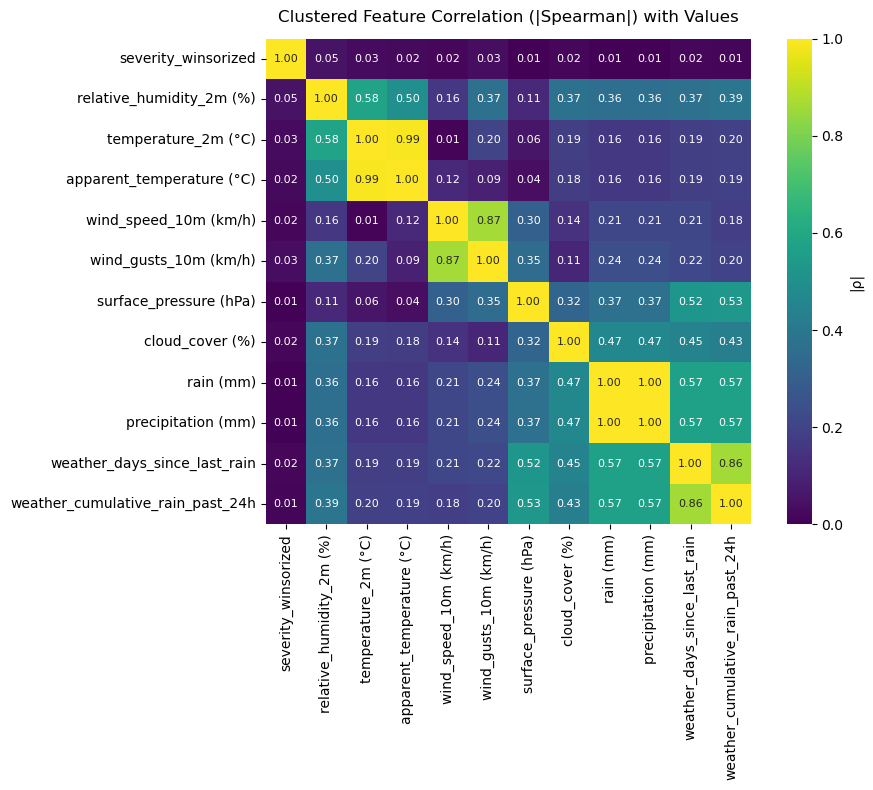

Found 8 feature clusters at distance threshold 0.3:

Cluster 1: ['temperature_2m (°C)', 'apparent_temperature (°C)']

Cluster 2: ['relative_humidity_2m (%)']

Cluster 3: ['wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)']

Cluster 4: ['rain (mm)', 'precipitation (mm)']

Cluster 5: ['weather_days_since_last_rain', 'weather_cumulative_rain_past_24h']

Cluster 6: ['cloud_cover (%)']

Cluster 7: ['surface_pressure (hPa)']

Cluster 8: ['severity_winsorized']


✓ severity_winsorized is in Cluster 8:
  Features: ['severity_winsorized']

  Correlations with severity_winsorized:
    severity_winsorized: 1.000


In [128]:
# Add severity_winsorized to numerical columns list
numerical_columns_for_analysis = numerical_columns_for_checking_correlation.copy()
if 'severity_winsorized' not in numerical_columns_for_analysis:
    numerical_columns_for_analysis.append('severity_winsorized')

# Copy and scale numerical features
num = df_accidents[numerical_columns_for_analysis].copy()
num_scaled = pd.DataFrame(
    RobustScaler().fit_transform(num),
    columns=num.columns,
    index=df_accidents.index
)

# Calculate Spearman absolute correlation
rho = num_scaled.corr(method="spearman").abs().fillna(0)
np.fill_diagonal(rho.values, 1.0)

# Prep distances and order by hierarchical clustering
dist = 1 - rho.copy()
np.fill_diagonal(dist.values, 0.0)
Z = linkage(squareform(dist.values, checks=False), method="average")
order = leaves_list(Z)
rho_ordered = rho.iloc[order, :].iloc[:, order]

# Plot clustered correlation matrix
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    rho_ordered,
    vmin=0, vmax=1, cmap="viridis",
    annot=True, fmt=".2f",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "|ρ|"},
    square=True
)
ax.set_title("Clustered Feature Correlation (|Spearman|) with Values", pad=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Convert correlation to distance metric
dist = 1 - rho.abs()
np.fill_diagonal(dist.values, 0)

# Convert square distance matrix to condensed vector form
D = squareform(dist.values, checks=False)

# Perform hierarchical clustering on features
Z = linkage(D, method="average")

# Cut dendrogram at distance threshold
distance_threshold = 0.3
clusters = fcluster(Z, t=distance_threshold, criterion="distance")

# Organize features into groups by cluster ID
feature_groups = {}
for feature_name, cluster_id in zip(dist.index, clusters):
    feature_groups.setdefault(cluster_id, []).append(feature_name)

# Display results
print(f"Found {len(feature_groups)} feature clusters at distance threshold {distance_threshold}:")
for cluster_id, features in sorted(feature_groups.items()):
    print(f"\nCluster {cluster_id}: {features}")

# Find which cluster contains severity_winsorized
print("\n" + "="*60)
for cluster_id, features in feature_groups.items():
    if 'severity_winsorized' in features:
        print(f"\n✓ severity_winsorized is in Cluster {cluster_id}:")
        print(f"  Features: {features}")
        print(f"\n  Correlations with severity_winsorized:")
        severity_corrs = rho.loc[features, 'severity_winsorized'].sort_values(
            ascending=False)
        for feat, corr in severity_corrs.items():
            print(f"    {feat}: {corr:.3f}")

Some of the features are highly correlated, so we should choose between one and the other in the clusters above where there are pairs of features. 

The correlations with accident severity are all low, however we should still keep some of these weather features. 
- Accident context matters: Hot humid afternoons might have different accident patterns than cold rainy mornings, even at same severity
- Driver behavior varies: hot/humid is valid - fatigue, AC use, different speeds
- Road conditions interact: Days since rain affects grip even in "dry" conditions
- Temporal patterns: Weather helps distinguish seasonal/temporal accident clusters

In [129]:
from scipy.stats import kruskal, chi2_contingency
from scipy.stats import f_oneway

# Test 1: Do weather variables differ across severity categories?
severity_categories = pd.cut(df_accidents['severity_winsorized'],
                             bins=[0, 1, 2, 3, float('inf')],
                             labels=['minor', 'moderate', 'serious', 'severe'])

print("="*60)
print("KRUSKAL-WALLIS TESTS: Weather vs Severity Category")
print("="*60)

weather_vars = numerical_columns_for_checking_correlation
for var in weather_vars:
    groups = [df_accidents[df_accidents['severity_winsorized'] == sev][var].dropna()
              for sev in df_accidents['severity_winsorized'].unique()]
    groups = [g for g in groups if len(g) > 0]  # remove empty groups

    if len(groups) >= 2:
        stat, p_value = kruskal(*groups)
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"{var:45s}: p={p_value:.4f} {sig}")

KRUSKAL-WALLIS TESTS: Weather vs Severity Category
temperature_2m (°C)                          : p=0.0061 **
apparent_temperature (°C)                    : p=0.0524 
relative_humidity_2m (%)                     : p=0.0000 ***
rain (mm)                                    : p=0.0210 *
precipitation (mm)                           : p=0.0204 *
surface_pressure (hPa)                       : p=0.1358 
cloud_cover (%)                              : p=0.1518 
wind_speed_10m (km/h)                        : p=0.3024 
wind_gusts_10m (km/h)                        : p=0.0014 **
weather_days_since_last_rain                 : p=0.0581 
weather_cumulative_rain_past_24h             : p=0.0566 


There is very strong evidence that humidity 'relative_humidity_2m (%)' varies across accident severities. 

There is strong evidence that temperature 'temperature_2m (°C)' (0.58 correlation with humidity) and wind gusts vary across accident severities.

There is some evidence that rain/precipitation varies across accident severities, however, this is already included in the categorical feature weather_group. 

Borderline: apparent_temperature (°C) but highly correlated with temperature, weather_days_since_last_rain and weather_cumulative_rain_past_24h

We will drop these:
- apparent_temperature (redundant with temperature + humidity)
- rain (use precipitation instead)
- weather_cumulative_rain_past_24h (use days_since_last_rain instead)
- surface_pressure (not significant)
- cloud_cover (not significant)
- wind_speed_10m (not significant, and gusts captures extremes)

In [131]:
# Test 2: Do weather variables differ by time of day (when accidents happen)?
print("\n" + "="*60)
print("KRUSKAL-WALLIS TESTS: Weather vs Natural light")
print("="*60)

for var in weather_vars:
    groups = [df_accidents[df_accidents['natural_light'] == phase][var].dropna()
              for phase in df_accidents['natural_light'].unique()]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) >= 2:
        stat, p_value = kruskal(*groups)
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"{var:45s}: p={p_value:.4f} {sig}")


KRUSKAL-WALLIS TESTS: Weather vs Natural light
temperature_2m (°C)                          : p=0.0000 ***
apparent_temperature (°C)                    : p=0.0000 ***
relative_humidity_2m (%)                     : p=0.0000 ***
rain (mm)                                    : p=0.0000 ***
precipitation (mm)                           : p=0.0000 ***
surface_pressure (hPa)                       : p=0.0000 ***
cloud_cover (%)                              : p=0.0000 ***
wind_speed_10m (km/h)                        : p=0.0000 ***
wind_gusts_10m (km/h)                        : p=0.0000 ***
weather_days_since_last_rain                 : p=0.0000 ***
weather_cumulative_rain_past_24h             : p=0.0000 ***


Weather conditions vary according to the time of day (no surprise there). However these weather variables may be proxies for the time of day, rather than independent factors. We already have phase of day and time of day (sin and cos). Putting in many weather variables might effectively be putting in time variables! 

In [132]:
weather_subset = ['temperature_2m (°C)', 'relative_humidity_2m (%)',
                  'precipitation (mm)', 'wind_gusts_10m (km/h)']

print("Correlations within weather subset:")
print(df_accidents[weather_subset].corr(method='spearman').round(2))

Correlations within weather subset:
                          temperature_2m (°C)  relative_humidity_2m (%)  \
temperature_2m (°C)                      1.00                     -0.58   
relative_humidity_2m (%)                -0.58                      1.00   
precipitation (mm)                      -0.16                      0.36   
wind_gusts_10m (km/h)                    0.20                     -0.37   

                          precipitation (mm)  wind_gusts_10m (km/h)  
temperature_2m (°C)                    -0.16                   0.20  
relative_humidity_2m (%)                0.36                  -0.37  
precipitation (mm)                      1.00                   0.24  
wind_gusts_10m (km/h)                   0.24                   1.00  


In [133]:
# Test 3: Correlation matrix between weather variables
print("\n" + "="*60)
print("WEATHER VARIABLE INTERCORRELATIONS")
print("="*60)

weather_corr = df_accidents[weather_vars].corr(method='spearman')
print(weather_corr)


WEATHER VARIABLE INTERCORRELATIONS
                                  temperature_2m (°C)  \
temperature_2m (°C)                          1.000000   
apparent_temperature (°C)                    0.988542   
relative_humidity_2m (%)                    -0.580299   
rain (mm)                                   -0.162758   
precipitation (mm)                          -0.163026   
surface_pressure (hPa)                      -0.056227   
cloud_cover (%)                             -0.186860   
wind_speed_10m (km/h)                       -0.009690   
wind_gusts_10m (km/h)                        0.201259   
weather_days_since_last_rain                 0.185301   
weather_cumulative_rain_past_24h            -0.195082   

                                  apparent_temperature (°C)  \
temperature_2m (°C)                                0.988542   
apparent_temperature (°C)                          1.000000   
relative_humidity_2m (%)                          -0.495636   
rain (mm)                  

In [134]:
numerical_columns_to_drop = ['apparent_temperature (°C)',
                             'rain (mm)',
                             'surface_pressure (hPa)',
                             'cloud_cover (%)',
                             'wind_speed_10m (km/h)',
                             'weather_cumulative_rain_past_24h']

df_accidents = df_accidents.drop(columns=numerical_columns_to_drop)

In [135]:
# Add to your numerical_for_clustering:
numerical_for_clustering.extend([
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain'
])

To avoid correlations between the number of female and male pedestrians hit, we introduce the feature: male_proportion

In [136]:
# Male Proportion (numeric feature - add to numerical_for_clustering)
df_accidents['male_proportion'] = df_accidents['num_male'] / \
    df_accidents['num_pedestrians_hit']
df_accidents['male_proportion'] = df_accidents['male_proportion'].fillna(
    0)  # handle division by zero

numerical_for_clustering.append('male_proportion')
# Keep the gender counts in numerical_to_keep_not_cluster for reference

In [137]:
numerical_for_clustering  # 10 features

['Latitude',
 'Longitude',
 'time_sin',
 'time_cos',
 'temperature_2m (°C)',
 'relative_humidity_2m (%)',
 'precipitation (mm)',
 'wind_gusts_10m (km/h)',
 'weather_days_since_last_rain',
 'male_proportion']

In [138]:
categorical_for_clustering  # 17 features

['severity_winsorized',
 'multiple_pedestrians',
 'driver_injury',
 'driver_gender',
 'natural_light',
 'DAY',
 'road_features',
 'road_markings_traffic_lights',
 'TipoStradaDifficulty',
 'traffic_density',
 'vehicle_type',
 'hit_and_run',
 'passengers',
 'road_conditions_bin',
 'road_signage',
 'weather_group']

### COLUMN CHECK

In [139]:
categorical_to_keep_not_cluster = ['Protocollo', 'total_injury_severity',
                                   'max_injury_severity', 'DataOraIncidente',]    # 4

numerical_to_keep_not_cluster = ['num_pedestrians_hit', 'num_male',
                                 'num_female', 'num_unknown_gender', 'doy_sin', 'doy_cos',]   # 6

Now we double-check we have every column included and no duplicates:

In [140]:
import difflib
from collections import Counter

df_cols = df_accidents.columns.tolist()
cat = list(categorical_for_clustering)
num = list(numerical_for_clustering)
cat_extra = list(categorical_to_keep_not_cluster)
num_extra = list(numerical_to_keep_not_cluster)

# De-dupe while preserving order for the combined "used" list
used_cols = []
for c in cat + num + cat_extra + num_extra:
    if c not in used_cols:
        used_cols.append(c)

# 1) In df but not in your lists
unaccounted_in_df = [c for c in df_cols if c not in used_cols]

# 2) In your lists but not in df  (these are your "extra columns" in the lists)
extra_in_lists = [c for c in used_cols if c not in df_cols]

# 3) Duplicates inside each list
dups_cat = [c for c, cnt in Counter(cat).items() if cnt > 1]
dups_num = [c for c, cnt in Counter(num).items() if cnt > 1]
dups_cat_extra = [c for c, cnt in Counter(cat_extra).items() if cnt > 1]
dups_num_extra = [c for c, cnt in Counter(num_extra).items() if cnt > 1]

# 4) Same column listed as both categorical and numerical
overlap = [c for c in cat if c in num]  # preserves order from categorical list

print("=== Coverage report ===")
print(f"Total df cols: {len(df_cols)}  | Used: {len(used_cols)}")
print(f"Unaccounted in df ({len(unaccounted_in_df)}): {unaccounted_in_df}")
print(
    f"Extra in your lists, not in df ({len(extra_in_lists)}): {extra_in_lists}")
print(f"Duplicates in categorical_cols: {dups_cat}")
print(f"Duplicates in numerical_cols:   {dups_num}")
print(f"Duplicates in categorical_cols extra: {dups_cat_extra}")
print(f"Duplicates in numerical_cols extra:   {dups_num_extra}")
print(f"Overlap between cat & num:      {overlap}")

# Dtypes for unaccounted columns (guard if empty)
if unaccounted_in_df:
    print("\nDtypes of unaccounted df columns:\n",
          df[unaccounted_in_df].dtypes)

# Fuzzy suggestions for extras (possible typos/renames)
if extra_in_lists:
    print("\nClosest matches for extras not in df:")
    for col in extra_in_lists:
        print(f"  {col} -> {difflib.get_close_matches(col, df_cols, n=3)}")

=== Coverage report ===
Total df cols: 36  | Used: 36
Unaccounted in df (0): []
Extra in your lists, not in df (0): []
Duplicates in categorical_cols: []
Duplicates in numerical_cols:   []
Duplicates in categorical_cols extra: []
Duplicates in numerical_cols extra:   []
Overlap between cat & num:      []


In [141]:
df_accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  category                   
 1   total_injury_severity         14849 non-null  category                   
 2   max_injury_severity           14849 non-null  category                   
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  category                   
 8   severity_winsorized           14849 non-null  category                   
 9   DataOraIncidente 

### SAVE PARQUET FILE - ALL INFORMATION

In [142]:
df_accidents.to_parquet('012_data_cluster_ready.parquet', index=False)

In [ ]:
metadata = {
    'notebook': '012 Clustering Cleaning.ipynb',
    'step': 'prepare model-ready dataset for clustering (k-prototypes): select features, prune redundancy, handle missing, collapse rare categories, scale numerics, export',

    # Lineage
    'input_file': "010_data_cleaned.parquet",
    'output_files': {
        'parquet': '012_data_cluster_ready.parquet'
    },

    # Shapes
    'initial_rows': '19406',
    'initial_columns': '63',
    'final_rows': '14849',
    'final_columns': '36',

    # Feature sets (before cleaning)
    'features_in': {
        'numeric': [
            'severity_winsorized', 'time_sin', 'time_cos', 'doy_sin', 'doy_cos',
            'temperature_2m (°C)', 'relative_humidity_2m (%)',
            'wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)',
            'precipitation (mm)', 'cloud_cover (%)'
            # + any other numerics you included
        ],
        'categorical': [
            # choose ONE representation for group size (keep only one here)
            'multiple_pedestrians',
            'phase_of_day', 'traffic_density',
            'road_conditions', 'road_surface', 'road_features',
            'accident_type', 'holiday_italy', 'is_weekend'
        ],
        'ordinal_codes': [
            # include only if you intend to treat these as numeric in some variants
            # otherwise keep the original ordered categoricals above
            # 'visibility_ord', 'road_conditions_ord', 'road_surface_ord', 'phase_of_day_ord'
        ],
        'id_columns': ['Protocollo'],
        'time_columns': ['DataOraIncidente', 'timestamp_local'],
        'geo_columns': ['Latitude', 'Longitude']
    },

    # Redundancy pruning
    'correlation_pruning': {
        'threshold_abs': 0.85,
        'pairs_dropped': [
            # examples from earlier analysis (already removed upstream); leave empty if nothing dropped here
            # ('total_injury_severity','severity_winsorized'),
            # ('max_injury_severity','severity_winsorized'),
            # ('num_pedestrians_hit','multiple_pedestrians')
        ],
        'constant_cols_removed': []
    },

    # Missing-data policy for clustering features
    'missing_data_policy': {
        'strategy': 'drop rows with NA in required clustering features',
        'required_blocks': {'numeric': 'all', 'categorical': 'all'},
        'rows_removed': '<fill>'
    },

    # Rare-category handling (to stabilise distance on simple-matching)
    'rare_category_policy': {
        'apply_to': ['accident_type', 'road_features', 'traffic_density'],
        # adjust if different
        'threshold': {'min_prop': 0.01, 'min_count': 100},
        'action': 'map to "Other"',
        'columns_changed': ['<fill>'],
        # number of levels collapsed per column
        'levels_collapsed': {'<col>': '<n>', '<col2>': '<n>'}
    },

    # Encoding & scaling (for k-prototypes)
    'encoding': {
        # all categoricals set to pandas CategoricalDtype
        'categorical_dtype': True,
        # kept ordered
        'ordered_categoricals': ['phase_of_day', 'road_conditions', 'road_surface'],
        'one_hot': False            # k-prototypes does not need one-hot
    },
    'scaling': {
        'numeric_scaler': 'RobustScaler',
        'features_scaled': [
            'severity_winsorized', 'time_sin', 'time_cos', 'doy_sin', 'doy_cos',
            'temperature_2m (°C)', 'relative_humidity_2m (%)',
            'wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)',
            'precipitation (mm)', 'cloud_cover (%)'
        ],
        'params': {'with_centering': True, 'with_scaling': True}
    },

    # Final feature lists used for export
    'features_final': {
        'numerical_for_clustering': ['Latitude', 'Longitude', 'time_sin', 'time_cos',
                                     'temperature_2m (°C)', 'relative_humidity_2m (%)',
                                     'precipitation (mm)', 'wind_gusts_10m (km/h)',
                                     'weather_days_since_last_rain', 'male_proportion'],
        'categorical_for_clustering': ['severity_winsorized', 'multiple_pedestrians',
                                       'driver_injury', 'driver_gender', 'phase_of_day',
                                       'DAY', 'road_features', 'road_markings_traffic_lights',
                                       'TipoStradaDifficulty', 'traffic_density', 'vehicle_type',
                                       'hit_and_run', 'passengers', 'road_conditions_bin',
                                       'road_signage', 'weather_group'],
        'categorical_to_keep_not_cluster': ['Protocollo', 'total_injury_severity',
                                            'max_injury_severity', 'DataOraIncidente'],    # 4
        'numerical_to_keep_not_cluster': ['num_pedestrians_hit', 'num_male',
                                          'num_female', 'num_unknown_gender', 'doy_sin', 'doy_cos',],   # 6
    },

    # QA checks
    'qa_checks': {
        'na_after_required_features': 0,
        'numeric_finite_all': True,
        'category_levels_after_collapse': {
            'accident_type': '<fill>', 'road_features': '<fill>', 'traffic_density': '<fill>'
        },
        'correlation_max_abs_after': '<fill>',
        'scaler_applied': True,
        'row_count_unchanged_after_scaling': True
    },

    # Suggested k-prototypes search defaults (stored here for reproducibility)
    'kprototypes_defaults': {
        'K_grid': [2, 3, 4, 5, 6, 7, 8, 9, 10],
        'gamma_grid': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
        'n_init': 10,
        'max_iter': 100,
        'random_state': 42
    },

    # Decisions & notes
    'decisions_made': [
        'Dataframe reduced from per pedestrian to per accident',
        'Data outside GRA eliminated',
        'Kept severity_winsorized as single severity signal to avoid collinearity.',
        'Represented group size with a single feature (binary or binned), not both.',
        'Collapsed rare categories (<1% or <100 rows) into Other to stabilise matching distance.',
        'Dropped rows with missing in required clustering features rather than imputing.',
        'Scaled numeric block with RobustScaler to reduce leverage of heavy tails.'
    ],
}